# Course Recommender System - Core Pipeline

In [1]:
import os
import re
import random
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from collections import defaultdict

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

# 1. Data Cleaning & Integration

In [2]:

def parse_coursera_duration(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if "less than" in s and "hour" in s:
        return 1.5

    m = re.search(r"(\d+)\s*meses", s)
    if m:
        return int(m.group(1)) * 120
    m = re.search(r"(\d+)\s*[-–]\s*(\d+)\s*month", s)
    if m:
        return ((int(m.group(1)) + int(m.group(2))) / 2) * 120
    m = re.search(r"(\d+)\s*month", s)
    if m:
        return int(m.group(1)) * 120
    m = re.search(r"(\d+)\s*[-–]\s*(\d+)\s*week", s)
    if m:
        return ((int(m.group(1)) + int(m.group(2))) / 2) * 20
    m = re.search(r"(\d+)\s*[-–]\s*(\d+)\s*year", s)
    if m:
        return ((int(m.group(1)) + int(m.group(2))) / 2) * 1440
    return np.nan

def parse_skillshare_duration(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    hours, mins = 0, 0
    h = re.search(r"(\d+)h", s)
    m = re.search(r"(\d+)m", s)
    if h: hours = int(h.group(1))
    if m: mins = int(m.group(1))
    return round(hours + mins / 60, 2)

def parse_udemy_duration(val):
    if pd.isna(val):
        return np.nan
    m = re.search(r"([\d.]+)\s*total\s*hour", str(val).lower())
    return float(m.group(1)) if m else np.nan

def parse_review_count(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower().replace(",", "")
    m = re.search(r"([\d.]+)\s*k", s)
    if m:
        return int(float(m.group(1)) * 1000)
    m = re.search(r"([\d.]+)\s*m", s)
    if m:
        return int(float(m.group(1)) * 1_000_000)
    try:
        return int(float(s))
    except ValueError:
        return np.nan

def parse_students(val):
    if pd.isna(val):
        return np.nan
    s = str(val).replace(",", "").replace("students", "").strip()
    try:
        return int(s)
    except ValueError:
        return np.nan

def clean_skills_str(val):
    if pd.isna(val):
        return ""
    s = str(val).replace("{", "").replace("}", "").replace('"', "")
    skills = [x.strip() for x in s.split(",") if x.strip()]
    return ", ".join(skills)

def normalize_level(val):
    if pd.isna(val):
        return "All Levels"
    s = str(val).strip().lower()
    if s in ("beginner", "introductory"):
        return "Beginner"
    elif s == "intermediate":
        return "Intermediate"
    elif s in ("advanced", "expert"):
        return "Advanced"
    return "All Levels"

# Category map helper

In [3]:
CATEGORY_MAP = {
    "Data Science": ["data science", "data analysis", "data analytics", "big data", "data engineering"],
    "Machine Learning": ["machine learning", "deep learning", "neural network", "nlp",
                         "computer vision", "artificial intelligence", "ai "],
    "Web Development": ["web development", "html", "css", "javascript", "react", "angular",
                         "node.js", "django", "flask", "frontend", "backend", "full stack", "web design"],
    "Mobile Development": ["android", "ios", "flutter", "react native", "swift", "kotlin", "mobile app"],
    "Cloud & DevOps": ["aws", "azure", "google cloud", "docker", "kubernetes", "devops",
                       "cloud computing", "terraform"],
    "Cybersecurity": ["cybersecurity", "ethical hacking", "penetration testing", "network security"],
    "Programming": ["python", "java ", "c++", "c#", "golang", "rust", "programming", "coding",
                    "software development", "algorithm"],
    "Database": ["sql", "mysql", "postgresql", "mongodb", "database", "nosql"],
    "Business": ["business", "management", "marketing", "finance", "accounting",
                 "project management", "entrepreneurship", "excel", "power bi", "tableau"],
    "Design": ["graphic design", "ui/ux", "ux design", "photoshop", "illustrator",
               "figma", "adobe", "animation", "3d modeling", "blender"],
    "Photography & Video": ["photography", "video editing", "filmmaking", "premiere",
                            "after effects", "cinematography"],
    "Music & Audio": ["music", "guitar", "piano", "audio", "sound design", "music production"],
    "Writing": ["writing", "copywriting", "content writing", "creative writing", "blogging"],
    "Personal Development": ["productivity", "communication skills", "public speaking",
                             "meditation", "time management"],
}

def guess_category(title):
    if pd.isna(title):
        return "Other"
    t = str(title).lower()
    for cat, keywords in CATEGORY_MAP.items():
        for kw in keywords:
            if kw in t:
                return cat
    return "Other"

# Process files and merge into a single df

In [4]:
def process_coursera(df):
    out = pd.DataFrame()
    out["title"] = df["course"].str.strip()
    out["platform"] = "Coursera"
    out["description"] = ""
    out["instructor"] = df["partner"].str.strip()
    out["skills"] = df["skills"].apply(clean_skills_str)
    out["level"] = df["level"].apply(normalize_level)
    out["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    out["review_count"] = df["reviewcount"].apply(parse_review_count)
    out["duration_hours"] = df["duration"].apply(parse_coursera_duration)
    out["url"] = ""

    out["category"] = ""
    for i, row in out.iterrows():
        cat = guess_category(row["skills"]) if row["skills"] else "Other"
        if cat == "Other":
            cat = guess_category(row["title"])
        out.at[i, "category"] = cat
    return out

def process_edx(df):
    df = df.dropna(subset=["title"]).copy()
    out = pd.DataFrame()
    out["title"] = df["title"].str.strip()
    out["platform"] = "edX"
    out["description"] = ""
    out["instructor"] = df["institution"].fillna("Unknown").str.strip()
    out["skills"] = df["associatedskills"].fillna("").str.strip()
    out["category"] = df["subject"].fillna("Other").str.strip()
    out["level"] = df["level"].apply(normalize_level)
    out["rating"] = np.nan
    out["review_count"] = np.nan
    out["duration_hours"] = np.nan
    out["url"] = df["link"].fillna("")
    return out

def process_skillshare(df):
    out = pd.DataFrame()
    out["title"] = df["title"].str.strip()
    out["platform"] = "Skillshare"
    out["description"] = ""
    out["instructor"] = df["instructor"].str.strip()
    out["skills"] = ""
    out["category"] = df["title"].apply(guess_category)
    out["level"] = "All Levels"
    out["rating"] = np.nan
    out["review_count"] = df["students"].apply(parse_students)
    out["duration_hours"] = df["duration"].apply(parse_skillshare_duration)
    out["url"] = df["link"].fillna("")
    return out

def process_udemy(df):
    out = pd.DataFrame()
    out["title"] = df["title"].str.strip()
    out["platform"] = "Udemy"
    out["description"] = df["description"].fillna("").str.strip()
    out["instructor"] = df["instructor"].str.strip()
    out["skills"] = ""
    out["category"] = df["title"].apply(guess_category)
    out["level"] = df["level"].apply(normalize_level)
    out["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    out["review_count"] = df["reviewcount"].apply(parse_review_count)
    out["duration_hours"] = df["duration"].apply(parse_udemy_duration)
    out["url"] = ""
    return out

def run_pipeline(data_dir="DATASET"):
    coursera = pd.read_csv(os.path.join(data_dir, "Coursera.csv"))
    edx = pd.read_csv(os.path.join(data_dir, "edx.csv"))
    skillshare = pd.read_csv(os.path.join(data_dir, "skillshare.csv"))
    udemy = pd.read_csv(os.path.join(data_dir, "Udemy.csv"))

    c = process_coursera(coursera)
    e = process_edx(edx)
    s = process_skillshare(skillshare)
    u = process_udemy(udemy)

    df = pd.concat([c, e, s, u], ignore_index=True)
    df = df.drop_duplicates(subset=["title", "platform"], keep="first")
    df = df[df["title"].str.len() >= 5].copy()

    for plat in df["platform"].unique():
        mask = (df["platform"] == plat) & (df["rating"].isna())
        med = df.loc[df["platform"] == plat, "rating"].median()
        if not pd.isna(med):
            df.loc[mask, "rating"] = med
    df["rating"] = df["rating"].fillna(df["rating"].median()).clip(1.0, 5.0)

    for plat in df["platform"].unique():
        mask = (df["platform"] == plat) & (df["duration_hours"].isna())
        med = df.loc[df["platform"] == plat, "duration_hours"].median()
        if not pd.isna(med):
            df.loc[mask, "duration_hours"] = med
    df["duration_hours"] = df["duration_hours"].fillna(df["duration_hours"].median()).round(1)
    df["review_count"] = df["review_count"].fillna(0).astype(int)

    df = df.reset_index(drop=True)
    df["course_id"] = range(1, len(df) + 1)

    df.to_csv(os.path.join(data_dir, "unified_courses.csv"), index=False, encoding="utf-8")
    return df

df = run_pipeline()
df.head()

,title,platform,description,instructor,skills,level,rating,review_count,duration_hours,url,category,course_id
0,Google Cybersecurity,Coursera,,Google,"Network Security, Python Programming, Linux, C...",Beginner,4.8,16400,540.0,,Cloud & DevOps,1
1,Google Data Analytics,Coursera,,Google,"Data Analysis, R Programming, SQL, Business Co...",Beginner,4.8,133400,540.0,,Data Science,2
2,Google Project Management:,Coursera,,Google,"Project Management, Strategy and Operations, L...",Beginner,4.8,97300,540.0,,Programming,3
3,Google Digital Marketing & E-commerce,Coursera,,Google,"Digital Marketing, Marketing, Marketing Manage...",Beginner,4.8,21400,540.0,,Data Science,4
4,Google IT Support,Coursera,,Google,"Computer Networking, Network Architecture, Net...",Beginner,4.8,181400,540.0,,Cloud & DevOps,5


# Quick Exploratory Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41911 entries, 0 to 41910
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           41911 non-null  object 
 1   platform        41911 non-null  object 
 2   description     41911 non-null  object 
 3   instructor      41911 non-null  object 
 4   skills          41911 non-null  object 
 5   level           41911 non-null  object 
 6   rating          41911 non-null  float64
 7   review_count    41911 non-null  int64  
 8   duration_hours  41911 non-null  float64
 9   url             41911 non-null  object 
 10  category        41911 non-null  object 
 11  course_id       41911 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.8+ MB

Platform Counts:
platform
Udemy         25799
Skillshare    14223
Coursera       1106
edX             783
Name: count, dtype: int64


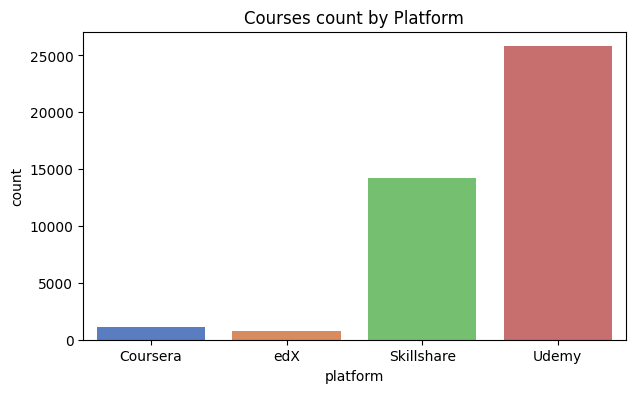

In [5]:
df.info()
print("\nPlatform Counts:")
print(df["platform"].value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="platform", palette="muted")
plt.title("Courses count by Platform")
plt.show()

# 2. Content-Based Filter

In [6]:
def build_text_blob(data):
    df_feat = data.copy()
    df_feat["description"] = df_feat["description"].fillna("")
    df_feat["skills"] = df_feat["skills"].fillna("")
    df_feat["category"] = df_feat["category"].fillna("")

    df_feat["text_blob"] = (
        df_feat["title"] + " " +
        df_feat["description"] + " " +
        df_feat["skills"] + " " +
        df_feat["category"] + " " +
        df_feat["level"]
    )
    df_feat["text_blob"] = df_feat["text_blob"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    return df_feat

df_feat = build_text_blob(df)
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(df_feat["text_blob"])

# Helper to match keywords

In [7]:
def query_courses(query, vectorizer, tfidf_matrix, data, top_n=10):
    vec = vectorizer.transform([query.lower()])
    sim = cosine_similarity(vec, tfidf_matrix).flatten()
    indices = sim.argsort()[::-1][:top_n]
    recs = data.iloc[indices][["course_id", "title", "platform", "category", "level", "rating"]].copy()
    recs["content_score"] = sim[indices]
    return recs

query_courses("python programming", vectorizer, tfidf_matrix, df, top_n=5)

,course_id,title,platform,category,level,rating,content_score
21858,21859,Python Programming,Udemy,Programming,All Levels,3.7,0.863861
20276,20277,Python Programming For Everyone,Udemy,Programming,Beginner,4.6,0.791783
18063,18064,Python for Beginners: Complete Python Programming,Udemy,Programming,Beginner,4.1,0.777793
19225,19226,Python for New learners: Introduction to pytho...,Udemy,Programming,Beginner,4.8,0.768805
16943,16944,Python Programming Beginners Tutorial : Python...,Udemy,Programming,Beginner,4.3,0.765387


# 3. Collaborative Filter

In [8]:
USER_PROFILES = {
    "data_science": ["data science", "machine learning", "python", "statistics", "deep learning", "data analysis"],
    "web_dev": ["web development", "javascript", "react", "html", "css", "node.js", "frontend", "backend"],
    "mobile_dev": ["android", "ios", "flutter", "react native", "swift"],
    "cloud": ["aws", "azure", "docker", "kubernetes", "devops"],
    "design": ["graphic design", "ui/ux", "figma", "photoshop"],
    "business": ["business", "marketing", "finance", "excel", "project management"],
    "cybersec": ["cybersecurity", "ethical hacking", "network security"]
}

def create_synthetic_ratings(data, num_users=1000):
    courses_by_profile = defaultdict(list)
    for idx, row in data.iterrows():
        combined = (str(row["title"]) + " " + str(row["category"]) + " " + str(row["skills"])).lower()
        for prof, tags in USER_PROFILES.items():
            if any(t in combined for t in tags):
                courses_by_profile[prof].append(row["course_id"])

    ratings_list = []
    for uid in range(1, num_users + 1):
        p1 = random.choice(list(USER_PROFILES.keys()))
        p2 = random.choice([p for p in USER_PROFILES.keys() if p != p1])
        candidates = courses_by_profile[p1] + courses_by_profile[p2]

        if len(candidates) < 10:
            candidates = data["course_id"].tolist()

        for cid in random.sample(candidates, min(random.randint(15, 25), len(candidates))):
            ratings_list.append({"user_id": uid, "course_id": cid, "rating": random.choice([4, 4, 5, 5])})

        non_match = list(set(data["course_id"].tolist()) - set(candidates))
        for cid in random.sample(non_match, min(random.randint(2, 5), len(non_match))):
            ratings_list.append({"user_id": uid, "course_id": cid, "rating": random.choice([1, 2, 2, 3])})

    return pd.DataFrame(ratings_list)

ratings = create_synthetic_ratings(df)
ratings.head()

,user_id,course_id,rating
0,1,18485,4
1,1,27744,4
2,1,27058,4
3,1,26549,4
4,1,11372,4


# Train and test SVD model

In [9]:
def run_evaluation(preds, k=10, threshold=3.5):
    user_ratings = defaultdict(list)
    for uid, _, true_r, est, _ in preds:
        user_ratings[uid].append((est, true_r))

    precisions = []
    recalls = []
    f1s = []
    aps = []
    ndcgs = []

    for uid, ratings_list in user_ratings.items():
        ratings_list.sort(key=lambda x: x[0], reverse=True)
        rel = sum(r >= threshold for (_, r) in ratings_list)
        rec_k = sum(est >= threshold for (est, _) in ratings_list[:k])
        rel_rec_k = sum((r >= threshold and est >= threshold) for (est, r) in ratings_list[:k])

        p = rel_rec_k / rec_k if rec_k > 0 else 0
        r = rel_rec_k / rel if rel > 0 else 0

        precisions.append(p)
        recalls.append(r)
        f1s.append(2 * (p * r) / (p + r) if (p + r) > 0 else 0)

        ap_sum = 0
        hits = 0
        for i, (est, r) in enumerate(ratings_list[:k]):
            if r >= threshold and est >= threshold:
                hits += 1
                ap_sum += hits / (i + 1)
        aps.append(ap_sum / min(rel, k) if rel > 0 else 0)

        hit_list = [1 if (r >= threshold and est >= threshold) else 0 for (est, r) in ratings_list[:k]]
        dcg = sum(hit_list[i] / np.log2(i + 2) for i in range(len(hit_list)))
        ideal = sorted(hit_list, reverse=True)
        idcg = sum(ideal[i] / np.log2(i + 2) for i in range(len(ideal)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    results = {
        "Precision@10": np.mean(precisions),
        "Recall@10": np.mean(recalls),
        "F1@10": np.mean(f1s),
        "MAP@10": np.mean(aps),
        "NDCG@10": np.mean(ndcgs)
    }

    for metric, val in results.items():
        print(f"{metric}: {val:.4f}")
    return results

reader = Reader(rating_scale=(1, 5))
dataset = Dataset.load_from_df(ratings[["user_id", "course_id", "rating"]], reader)
train_df, test_df = train_test_split(dataset, test_size=0.2, random_state=42)

model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
model.fit(train_df)

preds = model.test(test_df)
metrics = run_evaluation(preds)

Precision@10: 0.8385
Recall@10: 0.9830
F1@10: 0.8952
MAP@10: 0.9140
NDCG@10: 0.9469


# Plot SVD results

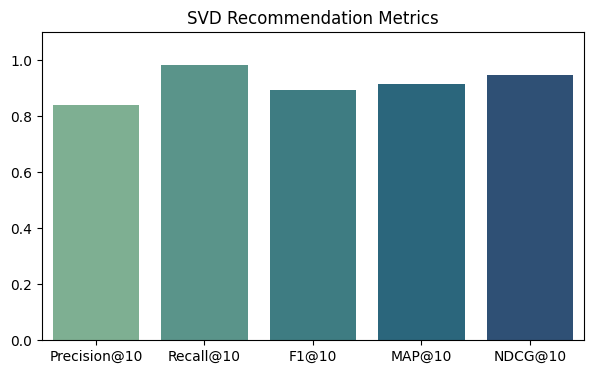

In [10]:
plt.figure(figsize=(7, 4))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="crest")
plt.title("SVD Recommendation Metrics")
plt.ylim(0, 1.1)
plt.show()

# 4. Hybrid Recommender

In [11]:
def get_hybrid_recommendations(skills, level, uid, vectorizer, tfidf_matrix, data, model, top_n=10, alpha=0.6):
    candidates = query_courses(skills + " " + level, vectorizer, tfidf_matrix, data, top_n=150)
    cids = candidates["course_id"].tolist()

    preds = []
    for cid in cids:
        preds.append({"course_id": cid, "predicted_rating": model.predict(uid, cid).est})
    df_preds = pd.DataFrame(preds)

    merged = candidates.merge(df_preds, on="course_id", how="left")
    merged["predicted_rating"] = merged["predicted_rating"].fillna(merged["predicted_rating"].median())

    c_min, c_max = merged["content_score"].min(), merged["content_score"].max()
    p_min, p_max = merged["predicted_rating"].min(), merged["predicted_rating"].max()

    merged["norm_content"] = (merged["content_score"] - c_min) / (c_max - c_min) if c_max > c_min else 0.5
    merged["norm_collab"] = (merged["predicted_rating"] - p_min) / (p_max - p_min) if p_max > p_min else 0.5

    merged["hybrid_score"] = alpha * merged["norm_collab"] + (1 - alpha) * merged["norm_content"]

    if level and level != "All Levels":
        merged.loc[merged["level"] == level, "hybrid_score"] += 0.1

    return merged.sort_values("hybrid_score", ascending=False).head(top_n)

full_trainset = dataset.build_full_trainset()
final_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
final_model.fit(full_trainset)

# 5. Learning Path Generator

In [12]:
def generate_learning_path(goal, vectorizer, tfidf_matrix, data):
    candidates = query_courses(goal, vectorizer, tfidf_matrix, data, top_n=100)

    path = []
    for lvl in ["Beginner", "Intermediate", "Advanced"]:
        subset = candidates[candidates["level"] == lvl]
        if not subset.empty:
            best = subset.sort_values(by=["rating", "content_score"], ascending=False).iloc[0]
            path.append({
                "step": len(path) + 1,
                "level": lvl,
                "title": best["title"],
                "platform": best["platform"],
                "rating": best["rating"]
            })

    if len(path) < 3:
        all_lvls = candidates[candidates["level"] == "All Levels"]
        for _, row in all_lvls.sort_values(by=["rating", "content_score"], ascending=False).iterrows():
            if len(path) >= 3:
                break
            if row["title"] not in [p["title"] for p in path]:
                path.append({
                    "step": len(path) + 1,
                    "level": "General/Specialization",
                    "title": row["title"],
                    "platform": row["platform"],
                    "rating": row["rating"]
                })

    return pd.DataFrame(path)

# Test Run

In [13]:
get_hybrid_recommendations("data science", "Beginner", 1, vectorizer, tfidf_matrix, df, final_model, top_n=5)

,course_id,title,platform,category,level,rating,content_score,predicted_rating,norm_content,norm_collab,hybrid_score
6,18854,Python and Data Science for beginners,Udemy,Data Science,Beginner,4.3,0.722881,4.157804,0.684208,0.805353,0.856895
35,16868,Careers in Data Science A-Z + AI & ChatGPT Bon...,Udemy,Data Science,Beginner,4.6,0.620871,4.266698,0.373767,0.973527,0.833623
0,24478,Be Aware of Data Science,Udemy,Data Science,Beginner,4.7,0.826649,3.989879,1.000000,0.546014,0.827608
66,19861,Real Life Machine Learning and Data Science Pr...,Udemy,Data Science,Beginner,4.9,0.577565,4.283840,0.241975,1.000000,0.796790
1,22169,Learn Data Science Basics,Udemy,Data Science,Beginner,3.3,0.793718,3.989879,0.899783,0.546014,0.787521


# Test Roadmap

In [14]:
generate_learning_path("machine learning engineer", vectorizer, tfidf_matrix, df)

,step,level,title,platform,rating
0,1,Beginner,Supervised Machine Learning: Regression and Cl...,Coursera,4.9
1,2,Intermediate,Convolutional Neural Networks,Coursera,4.9
2,3,Advanced,Introduction to Machine Learning in Production,Coursera,4.8
